Total beacon records: 2543
Time range: 5.60 s .. 214.23 s

 [1] BEACON SOURCE DISTRIBUTION
            n  t_first_s  t_last_s  frame_min  frame_max  npeers_mean  vbat_mean
senderId                                                                        
2         857      5.599   214.107          0        856     1.550758   7.612345
3         847      8.061   214.170         10        856     1.780401   7.400000
4         839     10.072   214.229         18        856     1.828367   8.306743

 [2] UWB DATA PRESENCE  (how many records have UWB filled)
  sender R2: 857 beacons, p1 valid=696, p2 valid=633
  sender R3: 847 beacons, p1 valid=838, p2 valid=670
  sender R4: 839 beacons, p1 valid=838, p2 valid=696

 [3] EXPANDING INTO PER-LINK RECORDS
Total link measurements: 4371

  link |    n |   raw_mean |  clean_mean |  clean_std |  rssi_mean |  temp_mean
----------------------------------------------------------------------------------------
  2->3 |  633 |   +42.1208 |     +2.2938 |     

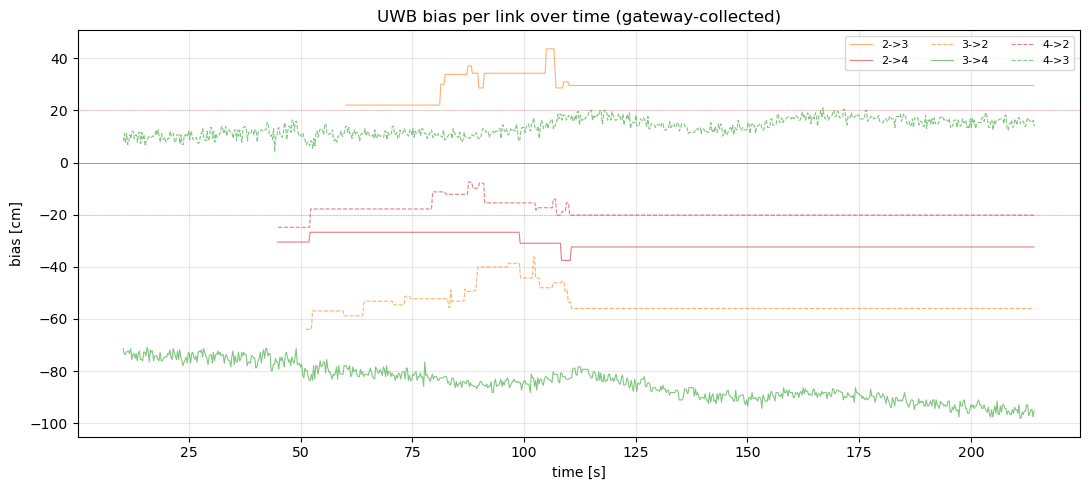

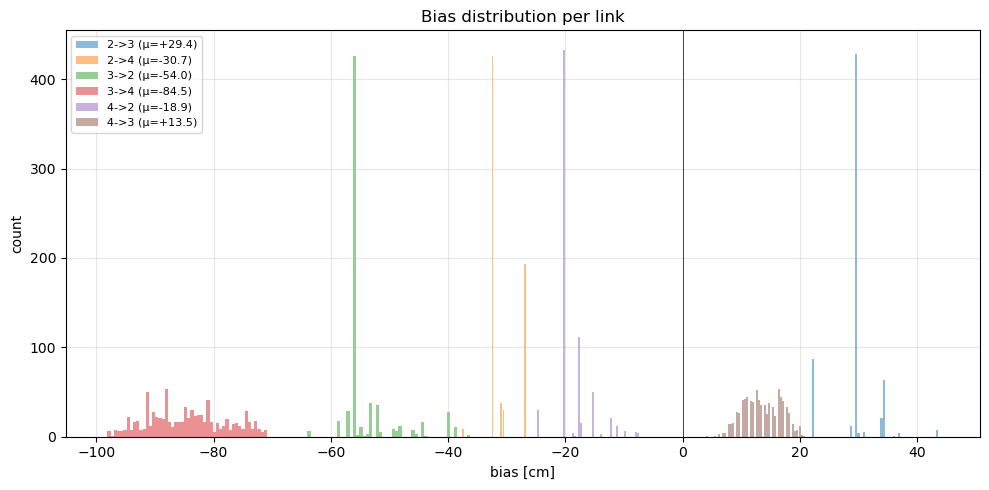

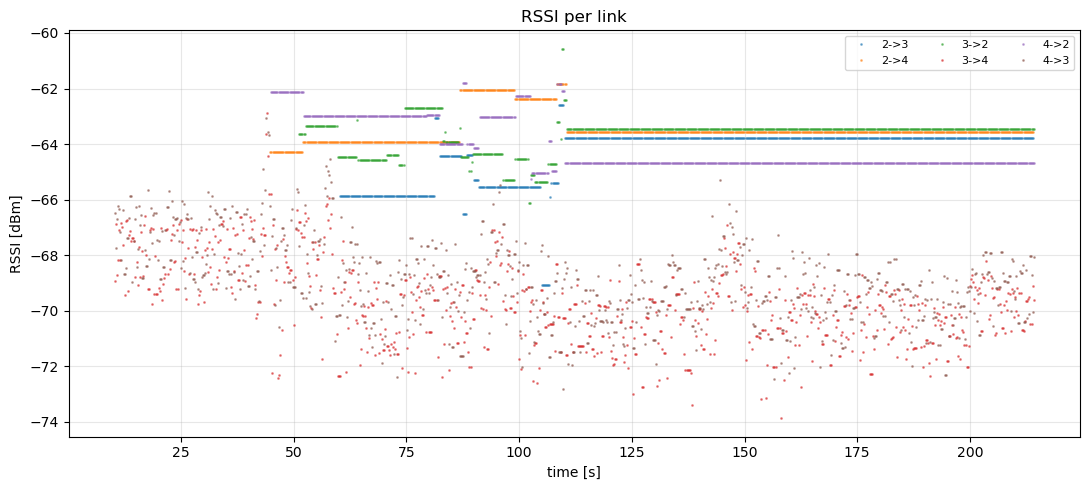

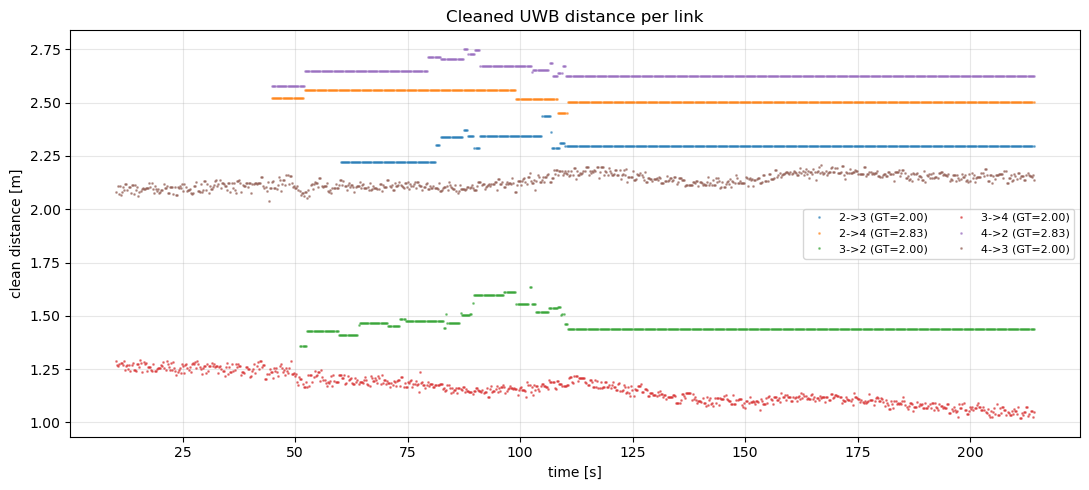

In [1]:
# ============================================================
# Gateway log analysis — 3-robot rotation, vertical antennas
# ============================================================
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 300)
np.set_printoptions(precision=4, suppress=True)

# ------------------------------------------------------------
# 0. Load and clean
# ------------------------------------------------------------
FILE = "first_test.csv"

rows = []
with open(FILE, "r") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        rows.append(line)

# First non-comment line is the header
header = rows[0].split(",")
data_rows = [r.split(",") for r in rows[1:]]

df = pd.DataFrame(data_rows, columns=header)
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print(f"Total beacon records: {len(df)}")
print(f"Time range: {df['rx_ms'].iloc[0]/1000:.2f} s .. "
      f"{df['rx_ms'].iloc[-1]/1000:.2f} s")

# ------------------------------------------------------------
# 1. Diagnostics
# ------------------------------------------------------------
print("\n" + "=" * 90)
print(" [1] BEACON SOURCE DISTRIBUTION")
print("=" * 90)
print(df.groupby("senderId").agg(
    n=("rx_ms", "size"),
    t_first_s=("rx_ms", lambda x: x.iloc[0] / 1000),
    t_last_s=("rx_ms",  lambda x: x.iloc[-1] / 1000),
    frame_min=("frameId", "min"),
    frame_max=("frameId", "max"),
    npeers_mean=("nPeers", "mean"),
    vbat_mean=("vbat", "mean"),
))

# ------------------------------------------------------------
# 2. UWB data presence
# ------------------------------------------------------------
print("\n" + "=" * 90)
print(" [2] UWB DATA PRESENCE  (how many records have UWB filled)")
print("=" * 90)

for sender in sorted(df["senderId"].unique()):
    sub = df[df["senderId"] == sender]
    n_total = len(sub)
    # Look at p1 and p2 for this sender
    has_p1 = (sub["p1_raw"].abs() > 1e-6).sum()
    has_p2 = (sub["p2_raw"].abs() > 1e-6).sum()
    print(f"  sender R{int(sender)}: {n_total} beacons, "
          f"p1 valid={has_p1}, p2 valid={has_p2}")

# ------------------------------------------------------------
# 3. Expand into per-link measurements
# ------------------------------------------------------------
print("\n" + "=" * 90)
print(" [3] EXPANDING INTO PER-LINK RECORDS")
print("=" * 90)

link_records = []
for _, row in df.iterrows():
    sender = int(row["senderId"])
    for slot in (1, 2):
        pid_col = f"p{slot}_id"
        if pid_col not in row.index: continue
        pid = int(row[pid_col])
        if pid == 0: continue
        raw_col   = f"p{slot}_raw"
        clean_col = f"p{slot}_clean"
        if abs(row[raw_col]) < 1e-6: continue

        link_records.append({
            "rx_ms":     row["rx_ms"],
            "sender":    sender,
            "peer":      pid,
            "frame":     int(row["frameId"]),
            "uptime_ms": row["uptimeMs"],
            "raw":       row[raw_col],
            "clean":     row[clean_col],
            "rssi":      row[f"p{slot}_rssi"],
            "fp":        row[f"p{slot}_fp"],
            "temp":      row[f"p{slot}_temp"],
            "lde":       row[f"p{slot}_lde"],
            "vbat":      row["vbat"],
        })

links = pd.DataFrame(link_records)
links["link"] = links["sender"].astype(str) + "->" + links["peer"].astype(str)
links["t_s"] = links["rx_ms"] / 1000.0

print(f"Total link measurements: {len(links)}")
print(f"\n{'link':>6s} | {'n':>4s} | {'raw_mean':>10s} | "
      f"{'clean_mean':>11s} | {'clean_std':>10s} | "
      f"{'rssi_mean':>10s} | {'temp_mean':>10s}")
print("-" * 88)
for lk, grp in links.groupby("link"):
    print(f"{lk:>6s} | {len(grp):>4d} | "
          f"{grp['raw'].mean():>+10.4f} | "
          f"{grp['clean'].mean():>+11.4f} | "
          f"{grp['clean'].std():>10.4f} | "
          f"{grp['rssi'].mean():>+10.2f} | "
          f"{grp['temp'].mean():>10.2f}")

# ------------------------------------------------------------
# 4. Bias vs constant ground truth
# ------------------------------------------------------------
print("\n" + "=" * 90)
print(" [4] BIAS vs CONSTANT GROUND TRUTH")
print("=" * 90)
print("  Rigid rotation, constant L=2m:")
print("    2↔3 = 2.000 m   (adjacent along Y)")
print("    3↔4 = 2.000 m   (adjacent along X)")
print("    2↔4 = 2.828 m   (diagonal)")

GT_DIST = {
    (2, 3): 2.000,
    (3, 2): 2.000,
    (3, 4): 2.000,
    (4, 3): 2.000,
    (2, 4): 2.828,
    (4, 2): 2.828,
}

print(f"\n{'link':>6s} | {'n':>4s} | {'GT':>7s} | "
      f"{'bias_mean':>10s} | {'bias_std':>10s} | "
      f"{'bias_min':>10s} | {'bias_max':>10s}")
print("-" * 80)
bias_summary = {}
for lk, grp in links.groupby("link"):
    s, p = map(int, lk.split("->"))
    gt = GT_DIST.get((s, p))
    if gt is None: continue
    bias = (grp["clean"] - gt) * 100
    bias_summary[lk] = {
        "gt": gt, "bias_mean": bias.mean(), "bias_std": bias.std(),
        "bias_min": bias.min(), "bias_max": bias.max(),
        "n": len(grp),
    }
    print(f"{lk:>6s} | {len(grp):>4d} | {gt:>7.3f} | "
          f"{bias.mean():>+10.2f} | {bias.std():>10.2f} | "
          f"{bias.min():>+10.2f} | {bias.max():>+10.2f}")
print("  (bias in cm)")

# ------------------------------------------------------------
# 5. Bias evolution over time (drift check)
# ------------------------------------------------------------
print("\n" + "=" * 90)
print(" [5] BIAS EVOLUTION OVER TIME  (4 windows)")
print("=" * 90)

for lk, grp in links.groupby("link"):
    s, p = map(int, lk.split("->"))
    gt = GT_DIST.get((s, p))
    if gt is None: continue
    if len(grp) < 20: continue

    t = grp["t_s"].values
    b = (grp["clean"].values - gt) * 100

    order = np.argsort(t)
    t = t[order]; b = b[order]

    n = len(b)
    q = n // 4
    w_means = [b[:q].mean(), b[q:2*q].mean(),
               b[2*q:3*q].mean(), b[3*q:].mean()]
    spread = max(w_means) - min(w_means)

    print(f"  {lk}: W1={w_means[0]:>+7.2f}  W2={w_means[1]:>+7.2f}  "
          f"W3={w_means[2]:>+7.2f}  W4={w_means[3]:>+7.2f}  "
          f"spread={spread:>6.2f} cm")

# ------------------------------------------------------------
# 6. Temperature anomaly check
# ------------------------------------------------------------
print("\n" + "=" * 90)
print(" [6] TEMPERATURE DATA CHECK")
print("=" * 90)
print("  Expected: chip temp should drift over 200 s due to heating.")
print(f"\n{'link':>6s} | {'temp_min':>9s} {'temp_max':>9s} | "
      f"{'temp_range':>11s} | {'unique_vals':>12s}")
print("-" * 60)
for lk, grp in links.groupby("link"):
    tv = grp["temp"].values
    uniq = len(np.unique(np.round(tv, 2)))
    print(f"{lk:>6s} | {tv.min():>9.2f} {tv.max():>9.2f} | "
          f"{tv.max()-tv.min():>11.3f} | {uniq:>12d}")

# ------------------------------------------------------------
# 7. Frame rate
# ------------------------------------------------------------
print("\n" + "=" * 90)
print(" [7] FRAME RATE CHECK")
print("=" * 90)
for sender in sorted(df["senderId"].unique()):
    sub = df[df["senderId"] == sender]
    if len(sub) < 2: continue
    t_span = (sub["rx_ms"].iloc[-1] - sub["rx_ms"].iloc[0]) / 1000
    dframe = sub["frameId"].iloc[-1] - sub["frameId"].iloc[0]
    rate = dframe / t_span if t_span > 0 else 0
    expected = 1000.0 / 240.0
    print(f"  R{int(sender)}: {len(sub)} beacons, "
          f"frame span {dframe} over {t_span:.1f}s, "
          f"rate = {rate:.3f} Hz (expected {expected:.3f})")

# ------------------------------------------------------------
# 8. Link asymmetry check
# ------------------------------------------------------------
print("\n" + "=" * 90)
print(" [8] LINK ASYMMETRY (same physical link, two directions)")
print("=" * 90)
pairs = [(2, 3), (3, 4), (2, 4)]
print(f"{'pair':>6s} | {'fwd bias':>10s} | {'rev bias':>10s} | {'Δ [cm]':>10s}")
print("-" * 50)
for a, b in pairs:
    fk = f"{a}->{b}"
    rk = f"{b}->{a}"
    if fk in bias_summary and rk in bias_summary:
        fb = bias_summary[fk]["bias_mean"]
        rb = bias_summary[rk]["bias_mean"]
        print(f"{a}↔{b} | {fb:>+10.2f} | {rb:>+10.2f} | {fb-rb:>+10.2f}")

# ------------------------------------------------------------
# 9. PLOT 1 — Bias per link over time
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 5))
colors = {"2->3": "tab:orange", "3->2": "tab:orange",
          "3->4": "tab:green",  "4->3": "tab:green",
          "2->4": "tab:red",    "4->2": "tab:red"}
styles = {"2->3": "-",  "3->2": "--",
          "3->4": "-",  "4->3": "--",
          "2->4": "-",  "4->2": "--"}
for lk, grp in links.groupby("link"):
    s, p = map(int, lk.split("->"))
    gt = GT_DIST.get((s, p))
    if gt is None: continue
    t = grp["t_s"].values
    b = (grp["clean"].values - gt) * 100
    order = np.argsort(t)
    ax.plot(t[order], b[order], styles.get(lk, "-"),
            color=colors.get(lk, "black"),
            lw=0.8, alpha=0.6, label=lk)
ax.axhline(0, color="gray", lw=0.5)
ax.axhline(+20, color="red", ls=":", lw=0.5, alpha=0.4)
ax.axhline(-20, color="red", ls=":", lw=0.5, alpha=0.4)
ax.set_xlabel("time [s]")
ax.set_ylabel("bias [cm]")
ax.set_title("UWB bias per link over time (gateway-collected)")
ax.legend(fontsize=8, ncol=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("p1_bias_time.png", dpi=120)
plt.show()

# ------------------------------------------------------------
# 10. PLOT 2 — Bias distribution per link
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
for lk, grp in links.groupby("link"):
    s, p = map(int, lk.split("->"))
    gt = GT_DIST.get((s, p))
    if gt is None: continue
    b = (grp["clean"].values - gt) * 100
    ax.hist(b, bins=50, alpha=0.5,
            label=f"{lk} (μ={b.mean():+.1f})")
ax.axvline(0, color="black", lw=0.5)
ax.set_xlabel("bias [cm]")
ax.set_ylabel("count")
ax.set_title("Bias distribution per link")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("p2_bias_hist.png", dpi=120)
plt.show()

# ------------------------------------------------------------
# 11. PLOT 3 — RSSI per link over time
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 5))
for lk, grp in links.groupby("link"):
    t = grp["t_s"].values
    r = grp["rssi"].values
    order = np.argsort(t)
    ax.plot(t[order], r[order], ".", ms=2, alpha=0.5, label=lk)
ax.set_xlabel("time [s]")
ax.set_ylabel("RSSI [dBm]")
ax.set_title("RSSI per link")
ax.legend(fontsize=8, ncol=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("p3_rssi.png", dpi=120)
plt.show()

# ------------------------------------------------------------
# 12. PLOT 4 — Clean distance per link over time
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 5))
for lk, grp in links.groupby("link"):
    t = grp["t_s"].values
    c = grp["clean"].values
    order = np.argsort(t)
    ax.plot(t[order], c[order], ".", ms=2, alpha=0.5,
            label=f"{lk} (GT={GT_DIST.get(tuple(map(int, lk.split('->'))), 0):.2f})")
ax.set_xlabel("time [s]")
ax.set_ylabel("clean distance [m]")
ax.set_title("Cleaned UWB distance per link")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("p4_clean_dist.png", dpi=120)
plt.show()

 [A] BIAS vs RSSI CORRELATION
  DW1000 has a documented RSSI-dependent bias (APS011).
  If bias is signal-strength dependent, RSSI correlates with bias.

  link |    n |   corr(bias,rssi) |  rssi_range |  bias_slope |  bias_at_-60dBm
----------------------------------------------------------------------------------------
  2->3 |  633 |            +0.038 |        6.47 |      +0.136 |          +29.97
  2->4 |  696 |            -0.036 |        2.48 |      -0.160 |          -31.29
  3->2 |  670 |            -0.570 |        5.56 |      -4.408 |          -70.22
  3->4 |  838 |            +0.447 |       10.98 |      +1.950 |          -65.58
  4->2 |  696 |            +0.297 |        3.45 |      +0.952 |          -15.02
  4->3 |  838 |            -0.420 |        9.73 |      -0.899 |           +5.50
  bias in cm, rssi in dBm, slope in cm/dBm

 [B] THE STEP CHANGE AROUND t=50s
  Data shows a ~15 cm bias jump and a ~4 dB RSSI jump around
  t=50s. The maneuver starts at frame 118 (~t=28s), so thi

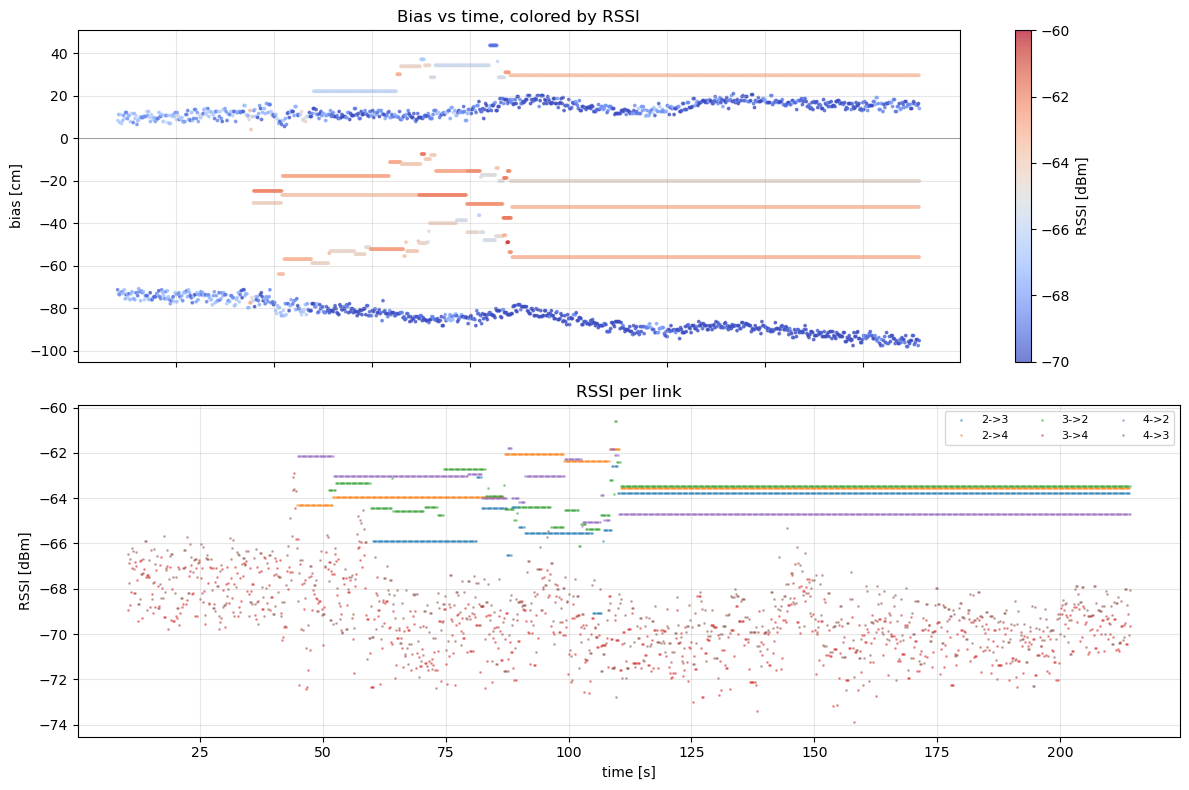

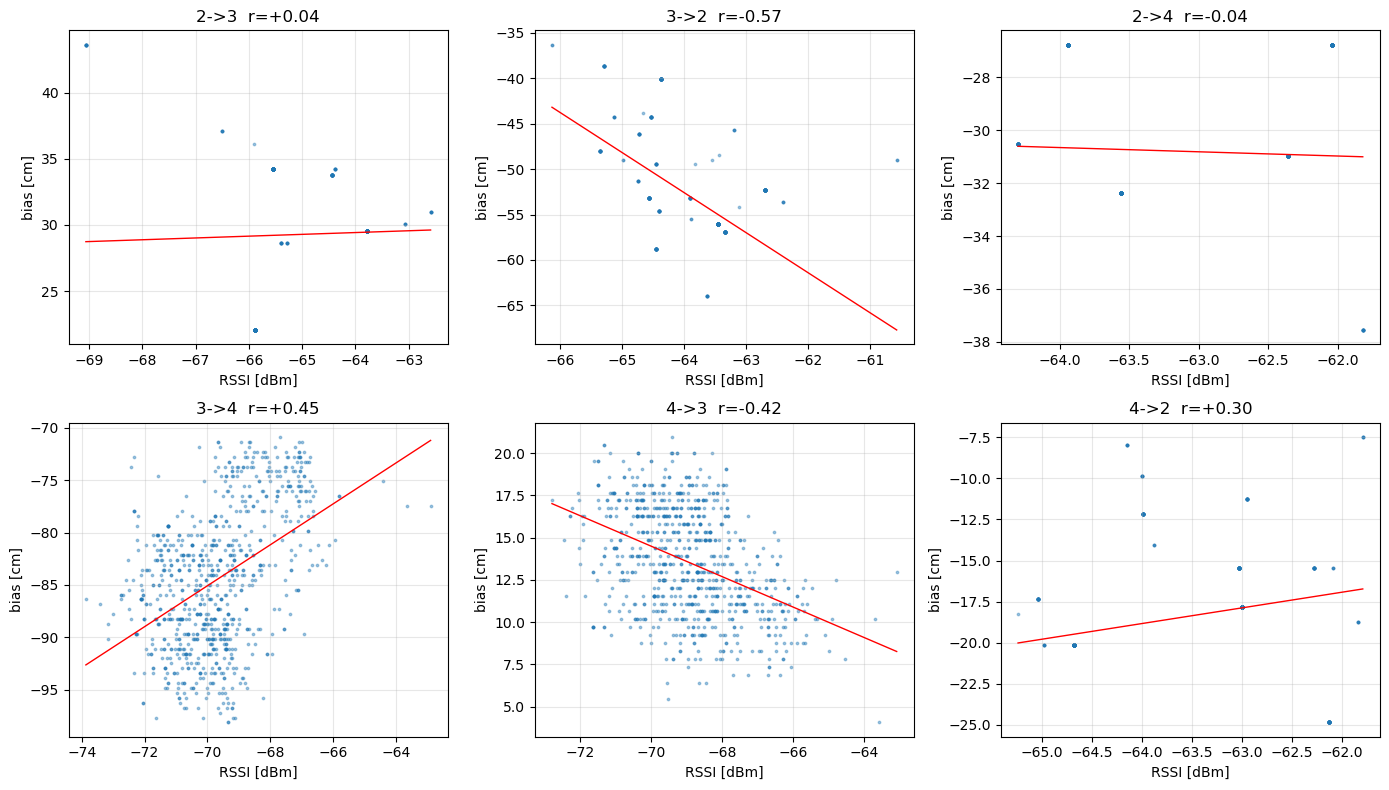

In [2]:
# ============================================================
# Deep analysis — gateway log, gateway-collected data
# ============================================================
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 300)
np.set_printoptions(precision=4, suppress=True)

# ------------------------------------------------------------
# 0. Reload (idempotent)
# ------------------------------------------------------------
FILE = "first_test.csv"
if "df" not in dir() or df is None:
    rows = []
    with open(FILE, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            rows.append(line)
    header = rows[0].split(",")
    data_rows = [r.split(",") for r in rows[1:]]
    df = pd.DataFrame(data_rows, columns=header)
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Build links table (idempotent)
if "links" not in dir() or links is None:
    recs = []
    for _, row in df.iterrows():
        sender = int(row["senderId"])
        for slot in (1, 2):
            pid = int(row[f"p{slot}_id"])
            if pid == 0: continue
            raw = row[f"p{slot}_raw"]
            if abs(raw) < 1e-6: continue
            recs.append({
                "rx_ms":   row["rx_ms"],
                "sender":  sender,
                "peer":    pid,
                "frame":   int(row["frameId"]),
                "raw":     raw,
                "clean":   row[f"p{slot}_clean"],
                "rssi":    row[f"p{slot}_rssi"],
                "fp":      row[f"p{slot}_fp"],
                "temp":    row[f"p{slot}_temp"],
                "lde":     row[f"p{slot}_lde"],
            })
    links = pd.DataFrame(recs)
    links["link"] = links["sender"].astype(str) + "->" + links["peer"].astype(str)
    links["t_s"] = links["rx_ms"] / 1000.0

GT_DIST = {
    "2->3": 2.000, "3->2": 2.000,
    "3->4": 2.000, "4->3": 2.000,
    "2->4": 2.828, "4->2": 2.828,
}

# ============================================================
# [A] BIAS vs RSSI CORRELATION  (is bias signal-strength dependent?)
# ============================================================
print("=" * 96)
print(" [A] BIAS vs RSSI CORRELATION")
print("=" * 96)
print("  DW1000 has a documented RSSI-dependent bias (APS011).")
print("  If bias is signal-strength dependent, RSSI correlates with bias.")
print(f"\n{'link':>6s} | {'n':>4s} | "
      f"{'corr(bias,rssi)':>17s} | {'rssi_range':>11s} | "
      f"{'bias_slope':>11s} | {'bias_at_-60dBm':>15s}")
print("-" * 88)

for lk, grp in links.groupby("link"):
    if lk not in GT_DIST: continue
    if len(grp) < 30: continue
    bias = (grp["clean"].values - GT_DIST[lk]) * 100
    rssi = grp["rssi"].values
    corr = float(np.corrcoef(bias, rssi)[0, 1])

    # Linear fit bias = a * rssi + b
    A = np.vstack([rssi, np.ones(len(rssi))]).T
    coef, *_ = np.linalg.lstsq(A, bias, rcond=None)
    slope = coef[0]
    intercept = coef[1]
    bias_at_minus60 = slope * (-60) + intercept

    print(f"{lk:>6s} | {len(grp):>4d} | "
          f"{corr:>+17.3f} | "
          f"{rssi.max()-rssi.min():>11.2f} | "
          f"{slope:>+11.3f} | "
          f"{bias_at_minus60:>+15.2f}")
print("  bias in cm, rssi in dBm, slope in cm/dBm")

# ============================================================
# [B] THE STEP CHANGE AT ~t=50s
# ============================================================
print("\n" + "=" * 96)
print(" [B] THE STEP CHANGE AROUND t=50s")
print("=" * 96)
print("  Data shows a ~15 cm bias jump and a ~4 dB RSSI jump around")
print("  t=50s. The maneuver starts at frame 118 (~t=28s), so this")
print("  transition is not the maneuver start.")

# For each link, split into two phases: pre-50s and post-60s
PHASE_SPLIT_S = 55.0

print(f"\n{'link':>6s} | "
      f"{'pre bias':>10s} {'pre rssi':>9s} | "
      f"{'post bias':>11s} {'post rssi':>10s} | "
      f"{'Δbias':>8s} {'Δrssi':>8s}")
print("-" * 92)

for lk, grp in links.groupby("link"):
    if lk not in GT_DIST: continue
    pre = grp[grp["t_s"] < PHASE_SPLIT_S]
    post = grp[grp["t_s"] > PHASE_SPLIT_S + 10]
    if len(pre) < 5 or len(post) < 20: continue

    pre_bias = (pre["clean"].values - GT_DIST[lk]).mean() * 100
    pre_rssi = pre["rssi"].mean()
    post_bias = (post["clean"].values - GT_DIST[lk]).mean() * 100
    post_rssi = post["rssi"].mean()

    print(f"{lk:>6s} | "
          f"{pre_bias:>+10.2f} {pre_rssi:>+9.2f} | "
          f"{post_bias:>+11.2f} {post_rssi:>+10.2f} | "
          f"{post_bias-pre_bias:>+8.2f} {post_rssi-pre_rssi:>+8.2f}")
print("  (bias cm, rssi dBm)")

# ============================================================
# [C] BIAS STABILITY  (post-maneuver window only)
# ============================================================
print("\n" + "=" * 96)
print(" [C] BIAS STABILITY  (t > 60s, when bias has settled)")
print("=" * 96)
print(f"{'link':>6s} | {'n':>4s} | "
      f"{'mean':>9s} | {'std':>8s} | "
      f"{'p5':>8s} | {'p95':>8s} | "
      f"{'ACF_1':>7s} | {'ACF_5':>7s}")
print("-" * 80)

for lk, grp in links.groupby("link"):
    if lk not in GT_DIST: continue
    g = grp[grp["t_s"] > 60]
    if len(g) < 30: continue

    bias = (g["clean"].values - GT_DIST[lk]) * 100
    mean = bias.mean()
    std = bias.std()
    p5, p95 = np.percentile(bias, [5, 95])

    # ACF: sort by time and compute autocorrelation at lags 1 and 5
    order = np.argsort(g["t_s"].values)
    b_sorted = bias[order]
    b_c = b_sorted - b_sorted.mean()
    n = len(b_c)

    def acf(lag):
        if lag >= n: return np.nan
        return float(np.corrcoef(b_c[:-lag], b_c[lag:])[0, 1])

    print(f"{lk:>6s} | {len(g):>4d} | "
          f"{mean:>+9.2f} | {std:>8.2f} | "
          f"{p5:>+8.2f} | {p95:>+8.2f} | "
          f"{acf(1):>+7.3f} | {acf(5):>+7.3f}")
print("  (all cm)")

# ============================================================
# [D] COVERAGE GAPS  (which slots are missed?)
# ============================================================
print("\n" + "=" * 96)
print(" [D] COVERAGE GAPS")
print("=" * 96)
print("  Expected ~856 frames per robot over the maneuver window.")
print("  Loss rate per link (missing polls or missing beacon):")

# Beacons per robot
print(f"\n{'robot':>5s} | {'n_beacon':>10s} | {'frame_span':>11s} | "
      f"{'beacon_loss%':>12s} | {'uwb_filled%':>11s}")
print("-" * 68)

for sender in sorted(df["senderId"].unique()):
    sub = df[df["senderId"] == sender]
    n_beacons = len(sub)
    frame_span = int(sub["frameId"].iloc[-1] - sub["frameId"].iloc[0])
    loss_pct = (1 - n_beacons / (frame_span + 1)) * 100

    # UWB filled for this sender
    filled = 0
    total = 0
    for slot in (1, 2):
        for _, row in sub.iterrows():
            if int(row[f"p{slot}_id"]) == 0: continue
            total += 1
            if abs(row[f"p{slot}_raw"]) > 1e-6: filled += 1

    filled_pct = 100 * filled / total if total > 0 else 0
    print(f"R{int(sender):>4d} | {n_beacons:>10d} | {frame_span:>11d} | "
          f"{loss_pct:>12.2f} | {filled_pct:>11.2f}")

# ============================================================
# [E] LINK ASYMMETRY  (definitive table)
# ============================================================
print("\n" + "=" * 96)
print(" [E] LINK ASYMMETRY  (definitive)")
print("=" * 96)
print(f"{'pair':>6s} | "
      f"{'fwd bias':>10s} {'fwd n':>6s} | "
      f"{'rev bias':>10s} {'rev n':>6s} | "
      f"{'|Δ| cm':>8s}")
print("-" * 72)

for a, b in [(2, 3), (3, 4), (2, 4)]:
    fk = f"{a}->{b}"
    rk = f"{b}->{a}"
    fg = links[links["link"] == fk]
    rg = links[links["link"] == rk]
    if len(fg) < 20 or len(rg) < 20: continue
    fb = (fg["clean"].mean() - GT_DIST[fk]) * 100
    rb = (rg["clean"].mean() - GT_DIST[rk]) * 100
    print(f"{a}↔{b} | "
          f"{fb:>+10.2f} {len(fg):>6d} | "
          f"{rb:>+10.2f} {len(rg):>6d} | "
          f"{abs(fb-rb):>8.2f}")

# ============================================================
# [F] TEMPERATURE BUG — full investigation
# ============================================================
print("\n" + "=" * 96)
print(" [F] TEMPERATURE BUG INVESTIGATION")
print("=" * 96)

print(f"  Unique temp values across all links: "
      f"{sorted(np.unique(links['temp'].values))}")
print(f"  Total link records with temp data: {len(links)}")
print(f"  Records with temp == 25.00: "
      f"{(links['temp'] == 25.0).sum()}")
print()
print("  Root cause hypothesis:")
print("    DW1000Ng::getTemperature() computes:")
print("      (sar_ltemp − _tmeas23C) × 1.14 + 23.0")
print("    If both sar_ltemp and _tmeas23C are 0 (or equal),")
print("    the result is constant.")
print("    Fix option A: read OTP calibration at boot and verify.")
print("    Fix option B: read BMI160 temperature instead (which works).")
print("    Fix option C: use the raw SAR reading without OTP calibration.")
print()

# ============================================================
# [G] PLOT — RSSI-colored bias over time
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top: bias with color = RSSI
ax = axes[0]
sc = None
for lk, grp in links.groupby("link"):
    if lk not in GT_DIST: continue
    t = grp["t_s"].values
    bias = (grp["clean"].values - GT_DIST[lk]) * 100
    rssi = grp["rssi"].values
    sc = ax.scatter(t, bias, c=rssi, cmap="coolwarm",
                    s=3, alpha=0.7, vmin=-70, vmax=-60)
ax.axhline(0, color="gray", lw=0.5)
ax.set_ylabel("bias [cm]")
ax.set_title("Bias vs time, colored by RSSI")
ax.grid(True, alpha=0.3)
if sc is not None:
    plt.colorbar(sc, ax=ax, label="RSSI [dBm]")

# Bottom: RSSI over time
ax = axes[1]
for lk, grp in links.groupby("link"):
    t = grp["t_s"].values
    rssi = grp["rssi"].values
    ax.plot(t, rssi, ".", ms=2, alpha=0.4, label=lk)
ax.set_xlabel("time [s]")
ax.set_ylabel("RSSI [dBm]")
ax.set_title("RSSI per link")
ax.legend(fontsize=8, ncol=3)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("p5_bias_vs_rssi.png", dpi=120)
plt.show()

# ============================================================
# [H] PLOT — scatter bias vs RSSI
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
links_list = [("2->3", axes[0, 0]), ("3->2", axes[0, 1]),
              ("2->4", axes[0, 2]),
              ("3->4", axes[1, 0]), ("4->3", axes[1, 1]),
              ("4->2", axes[1, 2])]
for lk, ax in links_list:
    grp = links[links["link"] == lk]
    if len(grp) < 20: continue
    bias = (grp["clean"].values - GT_DIST[lk]) * 100
    rssi = grp["rssi"].values
    ax.scatter(rssi, bias, s=3, alpha=0.4)
    # Fit line
    A = np.vstack([rssi, np.ones(len(rssi))]).T
    coef, *_ = np.linalg.lstsq(A, bias, rcond=None)
    r = np.corrcoef(rssi, bias)[0, 1]
    xx = np.linspace(rssi.min(), rssi.max(), 20)
    ax.plot(xx, coef[0] * xx + coef[1], "r-", lw=1)
    ax.set_title(f"{lk}  r={r:+.2f}")
    ax.set_xlabel("RSSI [dBm]")
    ax.set_ylabel("bias [cm]")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("p6_bias_rssi_scatter.png", dpi=120)
plt.show()